# 2D seismic refraction: one layer over a half-space

An interactive demo for a **single horizontal interface**: a layer of velocity $V_1$ and
thickness $h$ over a half-space of velocity $V_2$. Move the sliders and watch the
travel-time curves and the ray paths change.

**Travel times** (source at $x=0$, receivers on the surface):

| arrival | travel time |
|---|---|
| direct wave | $t = x / V_1$ |
| reflection | $t = \sqrt{x^2 + 4h^2}\,/\,V_1$ |
| head wave (refraction) | $t = \dfrac{x}{V_2} + \underbrace{\dfrac{2h\cos\theta_c}{V_1}}_{t_i\ \text{intercept}}$ |

with the critical angle $\theta_c = \arcsin(V_1/V_2)$, which requires $V_2 > V_1$.

Two distances matter:

- **critical distance** $x_{crit} = 2h\tan\theta_c$ — the head wave does not exist closer in
- **crossover distance** $x_{cross} = 2h\sqrt{\dfrac{V_2+V_1}{V_2-V_1}}$ — beyond it the head wave arrives first

Inverting the intercept time for depth: $\;h = \dfrac{t_i\,V_1V_2}{2\sqrt{V_2^2-V_1^2}}$

> Run the cells in order (`Runtime > Run all` works too).


In [ ]:
# Everything here ships with Colab. Uncomment if you are on a bare local kernel.
# !pip install -q numpy matplotlib ipywidgets

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Checkbox

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print("ready")


ready


## The forward model

One function returns every arrival plus the derived geometry. The head wave is set to
`NaN` inside the critical distance, where it physically does not exist.


In [ ]:
def two_layer_model(x, h, v1, v2):
    """Travel times for a layer (v1, thickness h) over a half-space (v2).

    Parameters
    ----------
    x  : offsets in m (array-like)
    h  : layer thickness in m
    v1 : layer velocity in m/s
    v2 : half-space velocity in m/s

    Returns a dict of travel times in seconds plus derived quantities.
    """
    x = np.atleast_1d(np.asarray(x, dtype=float))

    t_direct  = x / v1
    t_reflect = np.sqrt(x**2 + 4.0 * h**2) / v1

    if v2 > v1:
        theta_c = np.arcsin(v1 / v2)                       # critical angle, rad
        t_int   = 2.0 * h * np.cos(theta_c) / v1           # intercept time, s
        x_crit  = 2.0 * h * np.tan(theta_c)                # critical distance, m
        x_cross = 2.0 * h * np.sqrt((v2 + v1) / (v2 - v1))  # crossover distance, m
        t_head  = np.where(x >= x_crit, x / v2 + t_int, np.nan)
    else:
        # No critical refraction when v2 <= v1: nothing turns back up.
        theta_c = t_int = x_crit = x_cross = np.nan
        t_head  = np.full_like(x, np.nan)

    t_first = np.minimum(t_direct, np.where(np.isnan(t_head), np.inf, t_head))

    return dict(x=x, t_direct=t_direct, t_reflect=t_reflect, t_head=t_head,
                t_first=t_first, theta_c=theta_c, t_int=t_int,
                x_crit=x_crit, x_cross=x_cross)


def depth_from_intercept(t_int, v1, v2):
    """Standard slope-intercept interpretation: intercept time -> layer thickness."""
    return t_int * v1 * v2 / (2.0 * np.sqrt(v2**2 - v1**2))


## Interactive demo

- **top panel** — travel-time curves. Dashed lines are the individual arrivals, the heavy
  black line is what a field crew would actually pick (the first arrival), and the triangles
  are the picks at each geophone.
- **bottom panel** — the model with the head-wave ray path for the offset you choose.

Things worth trying: shrink $V_2$ toward $V_1$ (the refractor branch flattens out and the
crossover runs off the end of the spread), or set $V_2 < V_1$ (a velocity inversion — the
refraction method simply fails, no head wave exists).


In [ ]:
Z_MAX = 60.0   # fixed depth axis so the interface visibly moves


def plot_refraction(h=15.0, v1=600.0, v2=2400.0, spread=120.0, n_geo=25,
                    ray_offset=80.0, show_reflection=False):

    x  = np.linspace(0.0, spread, 601)
    xg = np.linspace(0.0, spread, n_geo)
    m, mg = two_layer_model(x, h, v1, v2), two_layer_model(xg, h, v1, v2)
    has_head = np.isfinite(m["theta_c"])

    fig, (ax_t, ax_m) = plt.subplots(
        2, 1, figsize=(8.2, 8.4), gridspec_kw=dict(height_ratios=[1.25, 1], hspace=0.30))

    # ---------------------------------------------------------------- travel times
    ax_t.plot(x, 1e3 * m["t_direct"], "--", color="0.45", lw=1.4,
              label=f"direct,  slope 1/{v1:.0f}")
    if show_reflection:
        ax_t.plot(x, 1e3 * m["t_reflect"], ":", color="seagreen", lw=1.6,
                  label="reflection")
    if has_head:
        ax_t.plot(x, 1e3 * m["t_head"], "--", color="firebrick", lw=1.4,
                  label=f"head wave,  slope 1/{v2:.0f}")
    ax_t.plot(x, 1e3 * m["t_first"], "-", color="k", lw=2.4, label="first arrival")
    ax_t.plot(xg, 1e3 * mg["t_first"], "v", ms=5, color="tab:blue",
              mec="k", mew=0.5, label="geophone picks", zorder=5)

    if has_head:
        if m["x_cross"] <= spread:
            ax_t.axvline(m["x_cross"], color="tab:orange", lw=1.0, ls="-.")
            ax_t.annotate(r"$x_{cross}$" + f" = {m['x_cross']:.1f} m",
                          xy=(m["x_cross"], 0.22 * 1e3 * spread / v1),
                          xytext=(4, 0), textcoords="offset points",
                          color="tab:orange", fontsize=9)
        ax_t.plot(0, 1e3 * m["t_int"], "o", color="firebrick", ms=5)
        ax_t.annotate(r"$t_i$" + f" = {1e3 * m['t_int']:.1f} ms",
                      xy=(0, 1e3 * m["t_int"]), xytext=(6, 8),
                      textcoords="offset points", color="firebrick", fontsize=9)
        info = (f"$\\theta_c$ = {np.degrees(m['theta_c']):.1f}$^\\circ$\n"
                f"$t_i$ = {1e3 * m['t_int']:.1f} ms\n"
                f"$x_{{crit}}$ = {m['x_crit']:.1f} m\n"
                f"$x_{{cross}}$ = {m['x_cross']:.1f} m\n"
                f"$h$ from $t_i$ = {depth_from_intercept(m['t_int'], v1, v2):.1f} m")
    else:
        info = "$V_2 \\leq V_1$:\nno critical refraction,\nno head wave"

    # The direct wave always runs corner to corner (the y-limit is set from it), so the
    # region above it on the left is the one reliably empty spot for text.
    ax_t.text(0.025, 0.66, info, transform=ax_t.transAxes, ha="left", va="top",
              fontsize=9, bbox=dict(fc="white", ec="0.7", alpha=0.9, pad=5))

    ax_t.set_xlim(0, spread)
    ax_t.set_ylim(0, 1.05e3 * spread / v1)
    ax_t.set_xlabel("offset  x  (m)")
    ax_t.set_ylabel("travel time  (ms)")
    ax_t.set_title("Travel-time curves")
    ax_t.grid(alpha=0.3)
    ax_t.legend(loc="upper left", fontsize=8.5, framealpha=0.9)

    # --------------------------------------------------------------------- model
    ax_m.axhspan(0, h, color="#ffe9b8")
    ax_m.axhspan(h, Z_MAX, color="#bcd4e6")
    ax_m.axhline(h, color="k", lw=1.6)
    ax_m.plot(xg, np.zeros_like(xg), "v", ms=5, color="tab:blue", mec="k", mew=0.5,
              clip_on=False, zorder=5)
    ax_m.plot([0], [0], "*", ms=17, color="crimson", mec="k", mew=0.5,
              clip_on=False, zorder=6)
    ax_m.annotate("source", xy=(0, 0), xytext=(2, 9), textcoords="offset points",
                  fontsize=9, color="crimson", ha="left", va="bottom",
                  annotation_clip=False)

    # Layer labels in DATA coordinates (y is depth and the axis is inverted, so
    # axes-fraction coordinates would put these in the wrong layer).
    lbl1 = f"$V_1$ = {v1:.0f} m/s,   $h$ = {h:.1f} m"
    if h >= 8.0:
        ax_m.text(0.985 * spread, 0.5 * h, lbl1, ha="right", va="center", fontsize=9)
    else:
        # Thin layer: park the label in the half-space and point back into the layer.
        ax_m.annotate(lbl1, xy=(0.88 * spread, 0.5 * h),
                      xytext=(0.985 * spread, h + 0.18 * Z_MAX),
                      ha="right", va="center", fontsize=9,
                      arrowprops=dict(arrowstyle="->", lw=0.9, color="0.3"))
    ax_m.text(0.985 * spread, h + 0.55 * (Z_MAX - h), f"$V_2$ = {v2:.0f} m/s",
              ha="right", va="center", fontsize=9)

    xr = min(ray_offset, spread)
    if has_head:
        dx = h * np.tan(m["theta_c"])          # horizontal run of one slanted leg
        if xr >= m["x_crit"] and xr > 0:
            ax_m.plot([0, dx, xr - dx, xr], [0, h, h, 0], "-", color="firebrick",
                      lw=1.8, zorder=4)
            ax_m.plot([xr], [0], "v", ms=8, color="firebrick", mec="k", mew=0.5,
                      clip_on=False, zorder=7)
            th = 1e3 * two_layer_model(xr, h, v1, v2)["t_head"][0]
            # anchor at the interface, then step DOWN-screen into the half-space
            ax_m.annotate(f"head wave to x = {xr:.0f} m  (t = {th:.1f} ms)",
                          xy=(xr, h), xytext=(-4, -16), textcoords="offset points",
                          ha="right", va="top", fontsize=9, color="firebrick")
        else:
            ax_m.plot([0, dx, 2 * dx], [0, h, 0], "--", color="firebrick", lw=1.4)
            ax_m.annotate(f"x = {xr:.0f} m is inside the critical distance\n"
                          f"(dashed = critical ray, turning point at "
                          f"{m['x_crit']:.1f} m)",
                          xy=(0.5, 0.62), xycoords="axes fraction", ha="center",
                          fontsize=9, color="firebrick")
    ax_m.plot([0, spread], [0, 0], color="k", lw=1.0)

    ax_m.set_xlim(0, spread)
    ax_m.set_ylim(Z_MAX, 0)
    ax_m.set_xlabel("distance  (m)")
    ax_m.set_ylabel("depth  (m)")
    ax_m.set_title("Model and head-wave ray path")

    plt.show()


In [ ]:
interact(
    plot_refraction,
    h          = FloatSlider(value=15,   min=1,   max=50,   step=0.5, description="h (m)"),
    v1         = FloatSlider(value=600,  min=300, max=2000, step=25,  description="V1 (m/s)"),
    v2         = FloatSlider(value=2400, min=400, max=6000, step=50,  description="V2 (m/s)"),
    spread     = FloatSlider(value=120,  min=10,  max=500,  step=11,  description="spread (m)"),
    n_geo      = IntSlider(  value=25,   min=5,   max=48,   step=1,   description="# geophones"),
    ray_offset = FloatSlider(value=80,   min=0,   max=300,  step=1,   description="ray to x (m)"),
    show_reflection = Checkbox(value=False, description="show reflection"),
);


interactive(children=(FloatSlider(value=15.0, description='h (m)', max=50.0, min=1.0, step=0.5), FloatSlider(v…

## Bonus: forward model, then invert it back

Generate noisy first-arrival picks from a known model, fit a straight line to the near
offsets and another to the far offsets, and recover $V_1$, $V_2$ and $h$. This is exactly
the slope-intercept workflow used on real refraction data.


crossover used to split branches:   31.6 m
V1: true   700.0   estimated   712.4 m/s
V2: true  2600.0   estimated  2738.4 m/s
h : true    12.0   estimated    12.5 m


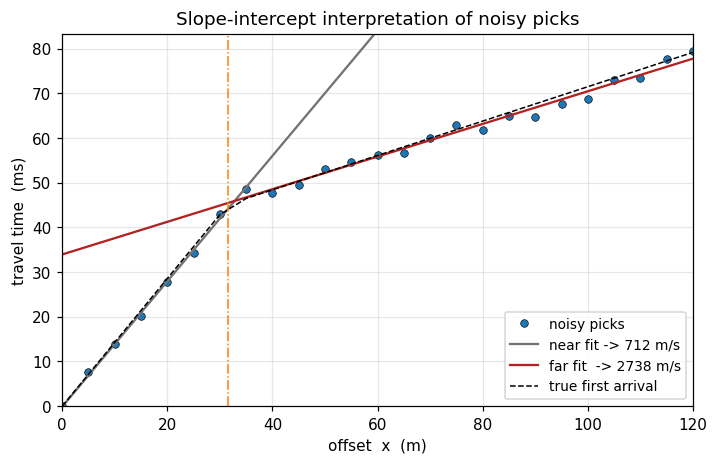

In [ ]:
rng = np.random.default_rng(7)

# --- true model ------------------------------------------------------------
h_true, v1_true, v2_true = 12.0, 700.0, 2600.0
xg = np.arange(0.0, 121.0, 5.0)

truth  = two_layer_model(xg, h_true, v1_true, v2_true)
t_obs  = truth["t_first"] + rng.normal(0.0, 1.5e-3, xg.size)   # 1.5 ms picking error

# --- pick the two branches (by eye in practice; here we use the crossover) --
x_cross = truth["x_cross"]
near = (xg > 0) & (xg < x_cross)
far  = xg > x_cross

s1, b1 = np.polyfit(xg[near], t_obs[near], 1)
s2, b2 = np.polyfit(xg[far],  t_obs[far],  1)

v1_est, v2_est, ti_est = 1.0 / s1, 1.0 / s2, b2
h_est = depth_from_intercept(ti_est, v1_est, v2_est)

print(f"crossover used to split branches: {x_cross:6.1f} m")
print(f"V1: true {v1_true:7.1f}   estimated {v1_est:7.1f} m/s")
print(f"V2: true {v2_true:7.1f}   estimated {v2_est:7.1f} m/s")
print(f"h : true {h_true:7.1f}   estimated {h_est:7.1f} m")

fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.plot(xg, 1e3 * t_obs, "o", ms=5, color="tab:blue", mec="k", mew=0.4, label="noisy picks")
ax.plot(xg, 1e3 * (s1 * xg + b1), "-",  color="0.45",     label=f"near fit -> {v1_est:.0f} m/s")
ax.plot(xg, 1e3 * (s2 * xg + b2), "-",  color="firebrick", label=f"far fit  -> {v2_est:.0f} m/s")
ax.plot(xg, 1e3 * truth["t_first"], "--", color="k", lw=1.0, label="true first arrival")
ax.axvline(x_cross, color="tab:orange", ls="-.", lw=1.0)
ax.set_xlim(0, xg.max()); ax.set_ylim(0, 1.05e3 * t_obs.max())
ax.set_xlabel("offset  x  (m)"); ax.set_ylabel("travel time  (ms)")
ax.set_title("Slope-intercept interpretation of noisy picks")
ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.show()


## Exercises

1. With $V_1 = 600$ and $V_2 = 2400$ m/s, how long a spread do you need to see the
   refractor for $h = 5$ m? For $h = 45$ m? A useful rule of thumb is that the spread
   should be 3-5x the target depth — check it against $x_{cross}$.
2. Keep $h$ fixed and slide $V_2$ from just above $V_1$ up to 6000 m/s. What happens to
   $\theta_c$, to $x_{crit}$, and to the length of the refractor branch you can record?
3. Set $V_2 < V_1$. The head wave disappears — this is the hidden-layer / velocity-inversion
   problem, a real limitation of the method.
4. In the inversion cell, raise the picking noise to 5 ms or drop the number of far-offset
   geophones. Which parameter degrades fastest: $V_1$, $V_2$, or $h$? (Watch how the
   intercept time is extrapolated from far offsets back to $x=0$.)
5. Extend the model: a **dipping** interface needs forward and reverse shots, and the two
   apparent velocities combine into the true $V_2$ and the dip. A good next step.

### Assumptions baked into this demo
Horizontal, planar interface; homogeneous isotropic layers; $V_2 > V_1$ for a head wave;
2D geometry with the source and receivers on a straight line; travel times only, no
amplitudes or waveforms.
